In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sellers = pd.read_csv("../../data/raw/olist_sellers_dataset.csv")

In [3]:
sellers

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [4]:
sellers.info()
sellers.isnull().sum()
sellers["seller_id"].nunique()
sellers["seller_id"].duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


np.int64(0)

In [5]:
seller_states = sellers["seller_state"].value_counts()
seller_states

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

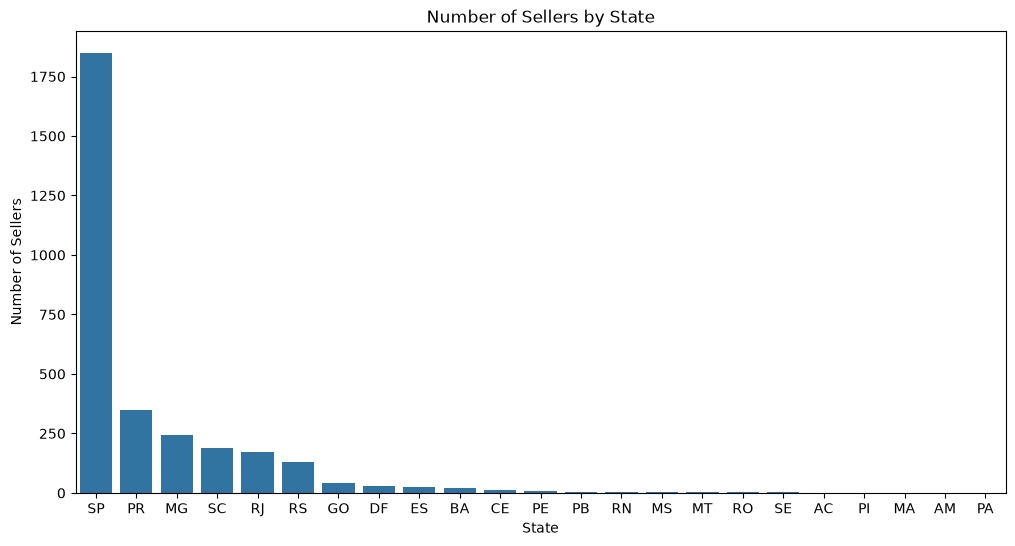

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(x=seller_states.index, y=seller_states.values)
plt.xlabel("State")
plt.ylabel("Number of Sellers")
plt.title("Number of Sellers by State")
plt.savefig("../../output/charts/sellers/sellers_by_state.png", dpi=300)
plt.show()

In [8]:
seller_cities = sellers["seller_city"].value_counts().head(15)
seller_cities

seller_city
sao paulo                694
curitiba                 127
rio de janeiro            96
belo horizonte            68
ribeirao preto            52
guarulhos                 50
ibitinga                  49
santo andre               45
campinas                  41
maringa                   40
sao jose do rio preto     33
sao bernardo do campo     32
osasco                    32
sorocaba                  32
brasilia                  28
Name: count, dtype: int64

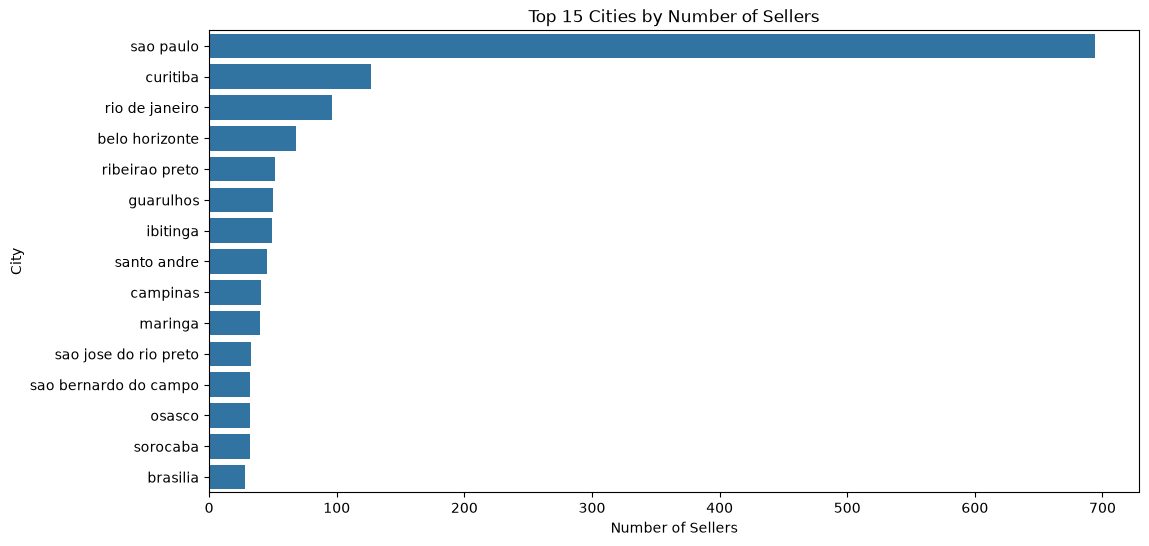

In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(x=seller_cities.values, y=seller_cities.index)
plt.xlabel("Number of Sellers")
plt.ylabel("City")
plt.title("Top 15 Cities by Number of Sellers")
plt.savefig("../../output/charts/sellers/top_seller_cities.png", dpi=300)
plt.show()

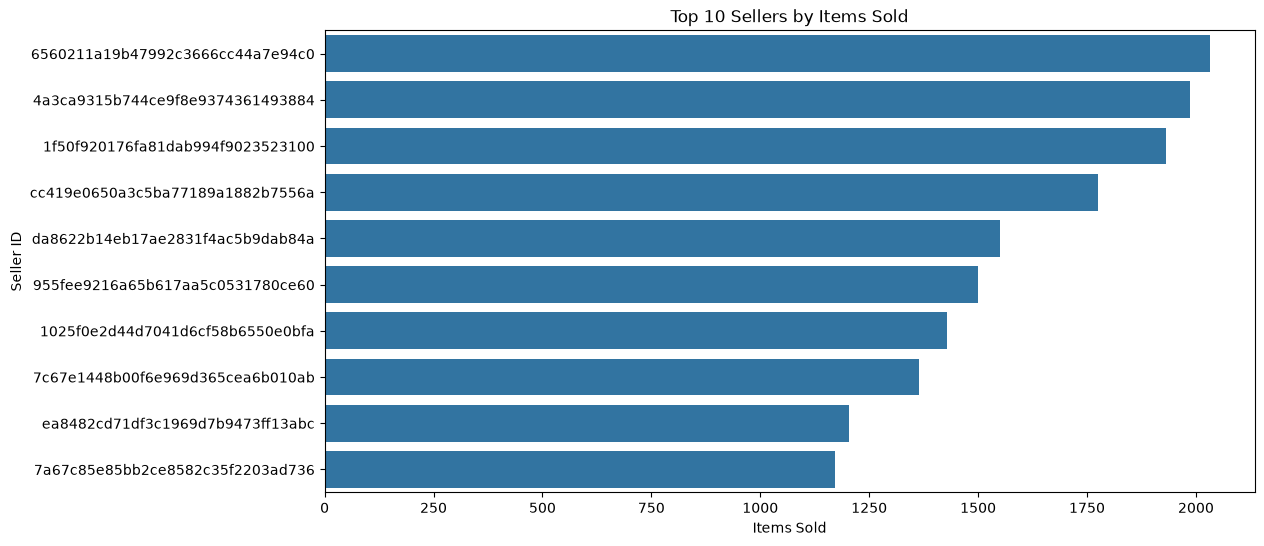

In [12]:
order_items = pd.read_csv("../../data/raw/olist_order_items_dataset.csv")

seller_activity = (
    order_items
    .groupby("seller_id")
    .agg(
        items_sold=("order_item_id", "count"),
        orders=("order_id", "nunique"),
        sales_value=("price", "sum")
    )
    .sort_values("items_sold", ascending=False)
)

top_sellers = seller_activity.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_sellers["items_sold"], y=top_sellers.index)
plt.xlabel("Items Sold")
plt.ylabel("Seller ID")
plt.title("Top 10 Sellers by Items Sold")
plt.savefig("../../output/charts/sellers/top_sellers_by_items.png", dpi=300)
plt.show()

## Key Observations

### 1. Seller Data Overview

- The dataset contains **3,095 sellers**.
- Every seller has a seller ID, ZIP-code prefix, city, and state.
- There are no missing values and no duplicate seller IDs.

### 2. Sellers by State

- Sellers are strongly concentrated in **São Paulo (SP)**, which has **1,849 sellers**.
- Paraná, Minas Gerais, Santa Catarina, Rio de Janeiro, and Rio Grande do Sul also have notable seller populations.
- The remaining states have relatively few sellers.

### 3. Sellers by City

- **São Paulo** is the city with the largest number of sellers, followed by Curitiba and Rio de Janeiro.
- The top cities are mainly large urban and commercial centers.
- This indicates that seller activity is geographically concentrated in major cities.

### 4. Seller Activity

- The order-items data was used to compare sellers by items sold, number of orders, and sales value.
- The top seller sold more than **2,000 items** in the dataset.
- A seller may have a high sales value even when their item count is not the highest, because product prices can differ.

### Overall Insight

Overall, the seller marketplace is concentrated in São Paulo and a small number of major cities and states. A relatively small group of sellers handles a large amount of item activity, while many other sellers contribute smaller volumes. This shows that seller location and seller size are not evenly distributed across the marketplace.